# Objectives
Dataset: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
1. Diabetes Classification (Y/N)
2. Feature importance and explainability
3. Early diabetes risk prediction
4. Clustering for risk group 


# Libraries and dependencies

In [1]:
pip install -r requirements.txt

   ---------------------------------------- 0.0/238.4 kB ? eta -:--:--
   --------------------------------------  235.5/238.4 kB 14.1 MB/s eta 0:00:01
   ---------------------------------------- 238.4/238.4 kB 7.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import ADASYN



# Load dataset

In [35]:
# Define the path correctly
dataset_path = "data/diabetes.csv"

# Load the CSV into a DataFrame
df = pd.read_csv(dataset_path)

df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [36]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [38]:
# Check for missing values
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [39]:
# Distribution of the 2 classes in Outcome column
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

# Exploratory Data Analysis (EDA)

In [40]:
# List of continuous numerical columns
X = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'
]

In [41]:
def plot_histograms(df, columns, title='Histograms for Numerical Columns'):
    """
    Plots histograms for the specified numerical columns in a DataFrame.

    Parameters:
        df (pd.DataFrame): The DataFrame containing the data.
        columns (list): List of numerical column names to plot.
        title (str): Title for the entire figure.
    """
    num_cols = len(columns)
    n_rows = (num_cols // 3) + (num_cols % 3 > 0)
    
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5 * n_rows))
    fig.suptitle(title, fontsize=16)
    
    axes = axes.flatten()
    
    for i, column in enumerate(columns):
        axes[i].hist(df[column].dropna(), bins=30, edgecolor='black')
        axes[i].set_title(column)
        axes[i].set_xlabel(column)
        axes[i].set_ylabel('Frequency')
    
    for j in range(len(columns), len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


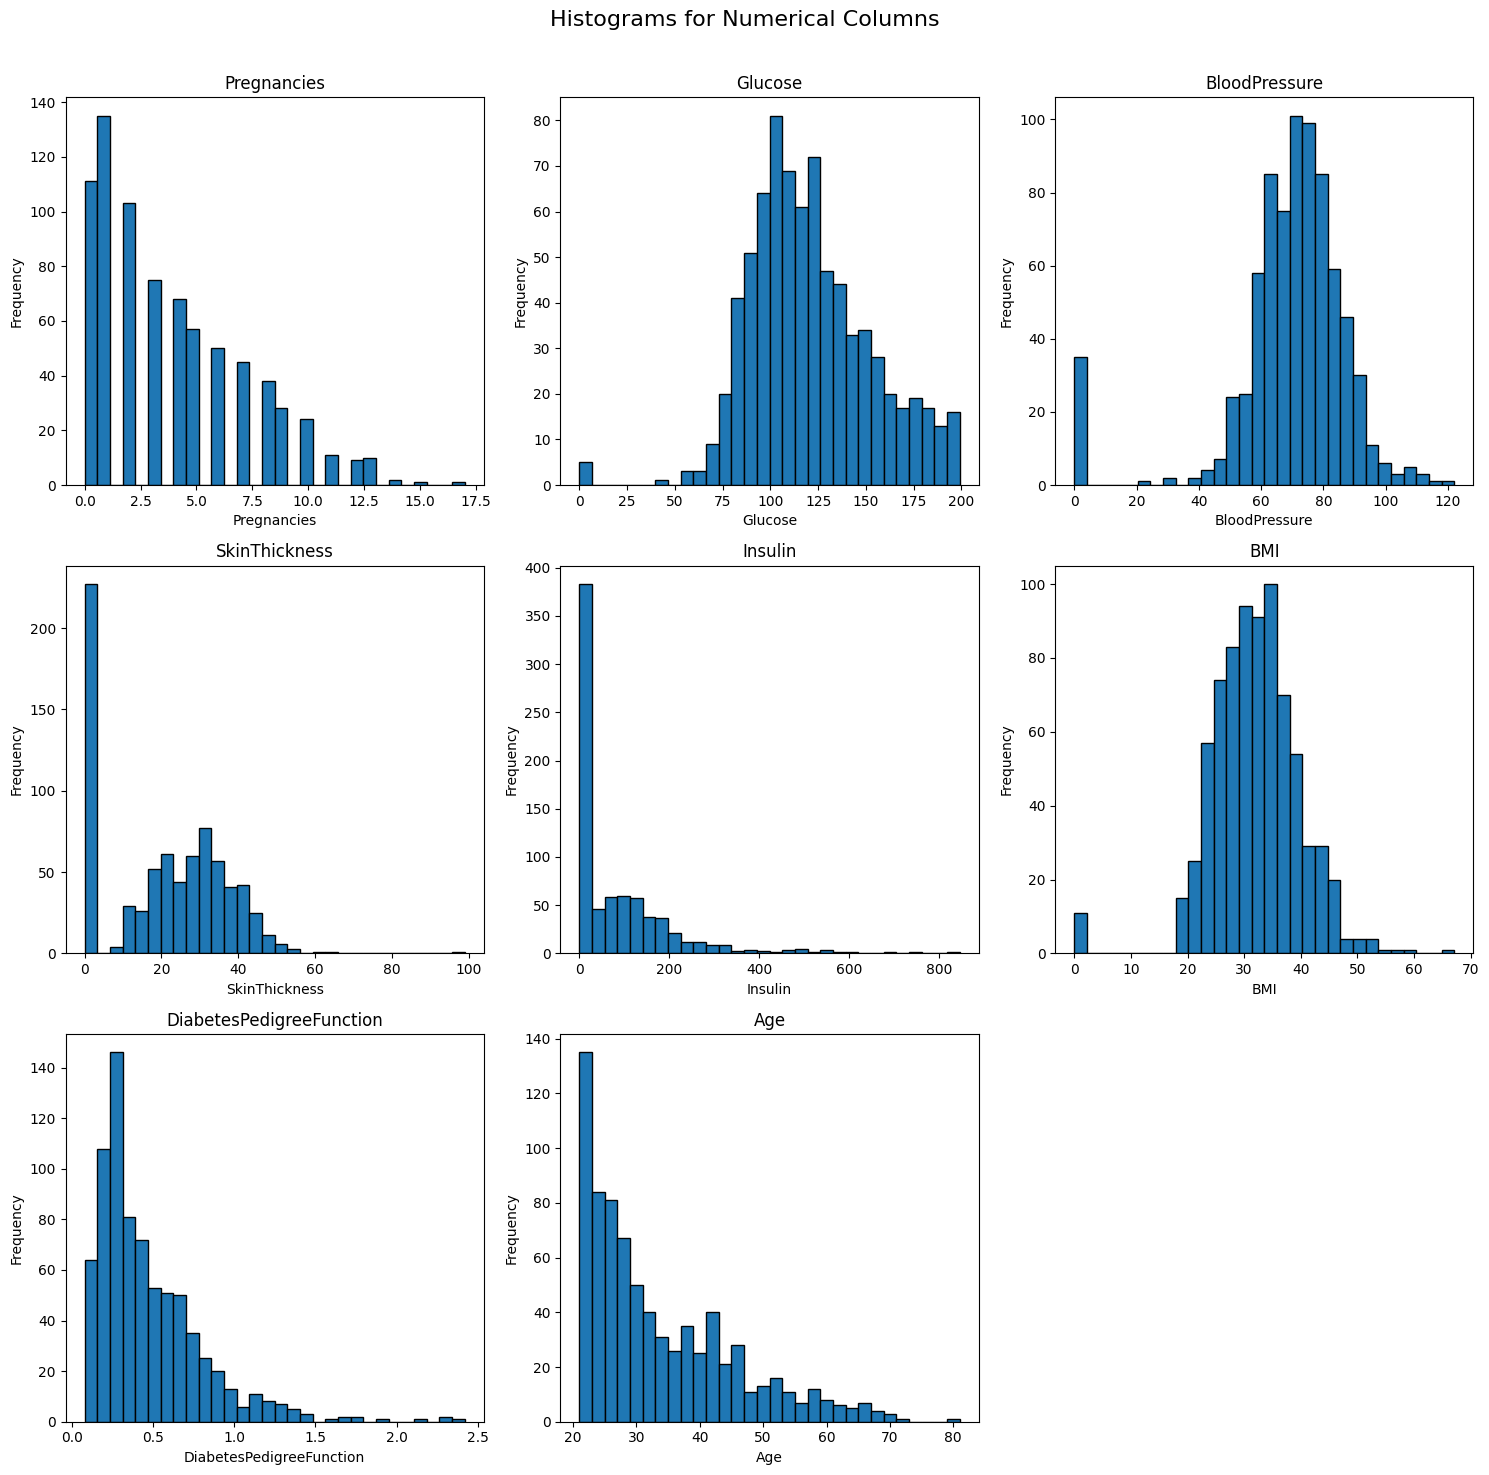

In [42]:
plot_histograms(df, X, title='Histograms for Numerical Columns')

# Replace 0 in appropriate columns with mean

In [43]:
# List of columns where 0 is invalid
invalid_zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace 0 with NaN
df[invalid_zero_cols] = df[invalid_zero_cols].replace(0, np.nan)

# Impute with mean
df[invalid_zero_cols] = df[invalid_zero_cols].fillna(df[invalid_zero_cols].mean())


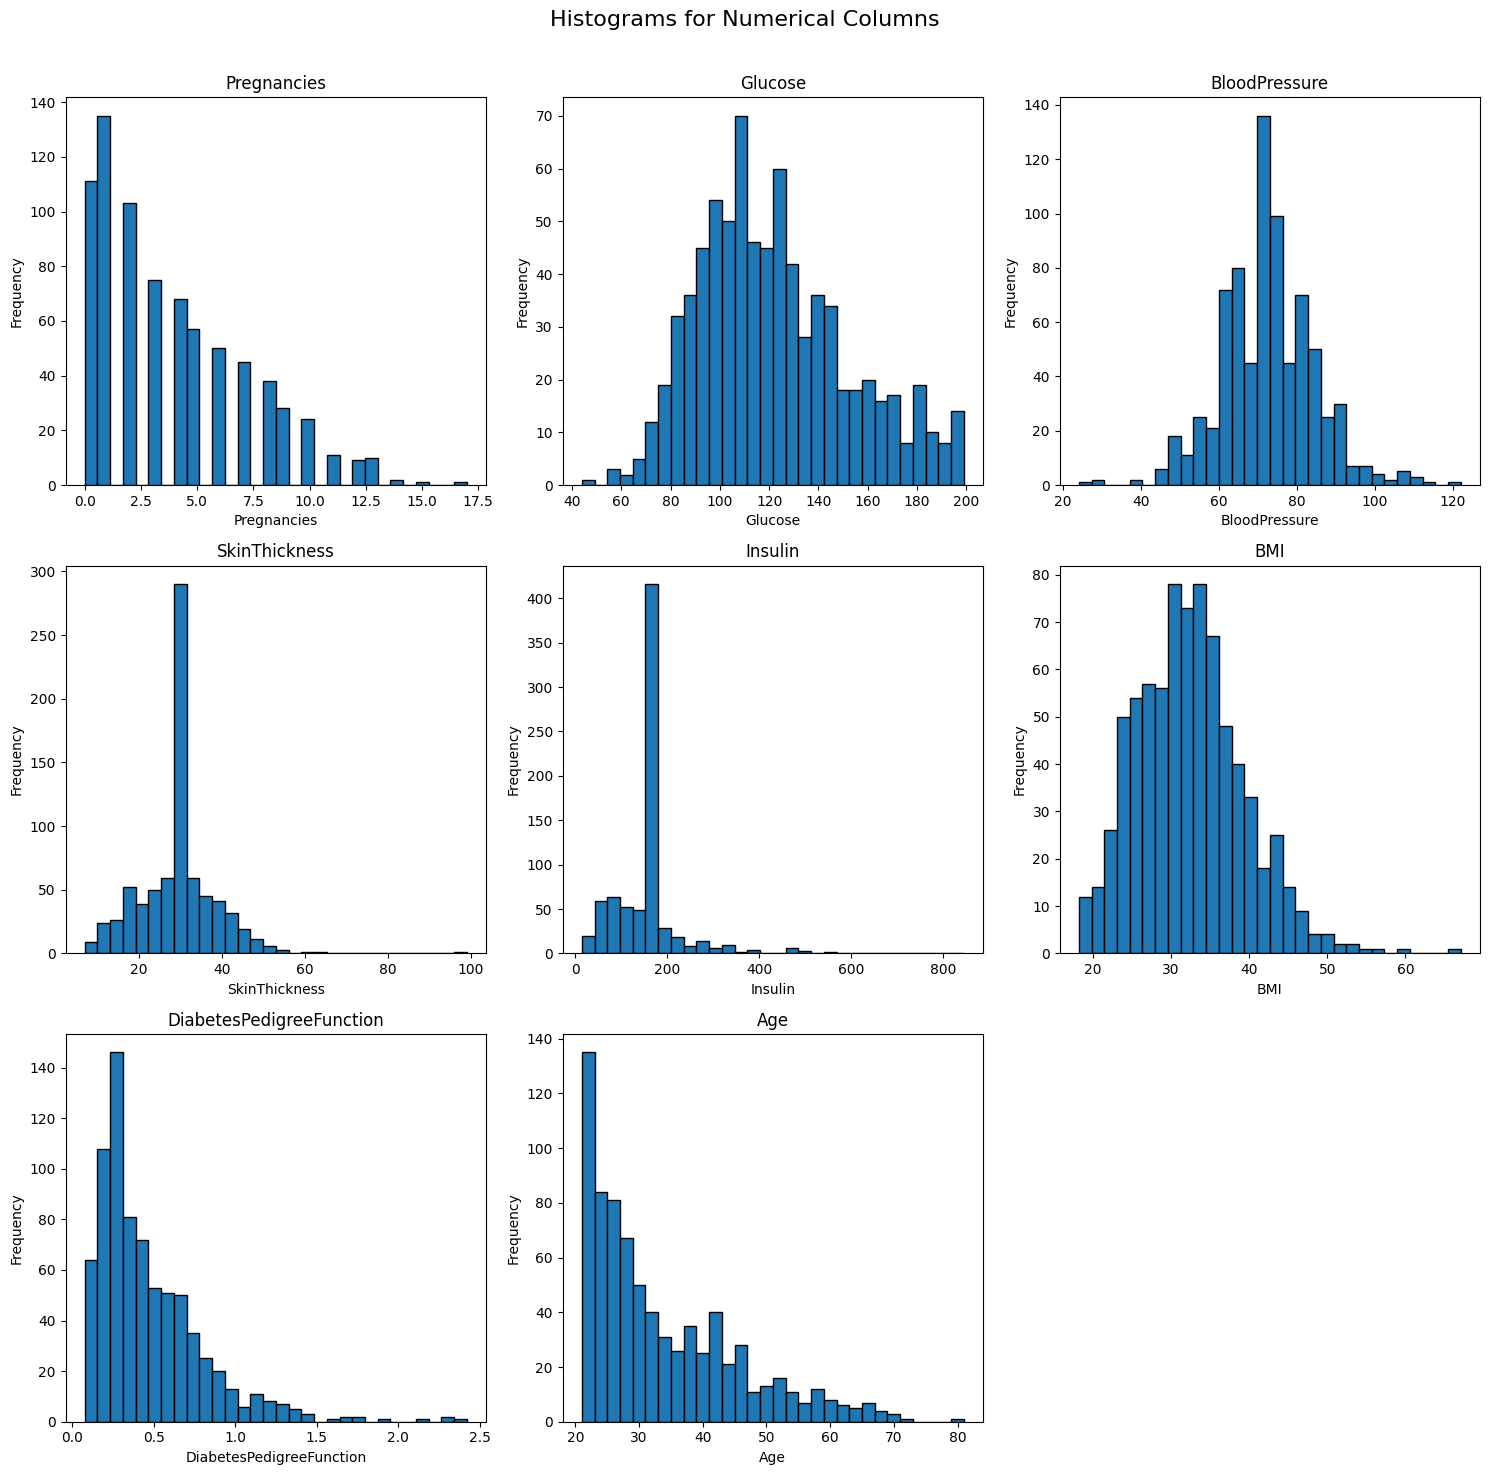

In [44]:
plot_histograms(df, X, title='Histograms for Numerical Columns')

# Remove outliers z-score>3

In [45]:
# Compute Z-scores only for the selected X columns
z_scores = np.abs(zscore(df[X]))

# Create a mask where all Z-scores are less than or equal to 3 across all X columns
mask = (z_scores <= 3).all(axis=1)

# Apply the mask to filter the DataFrame
df_no_outliers = df[mask].reset_index(drop=True)

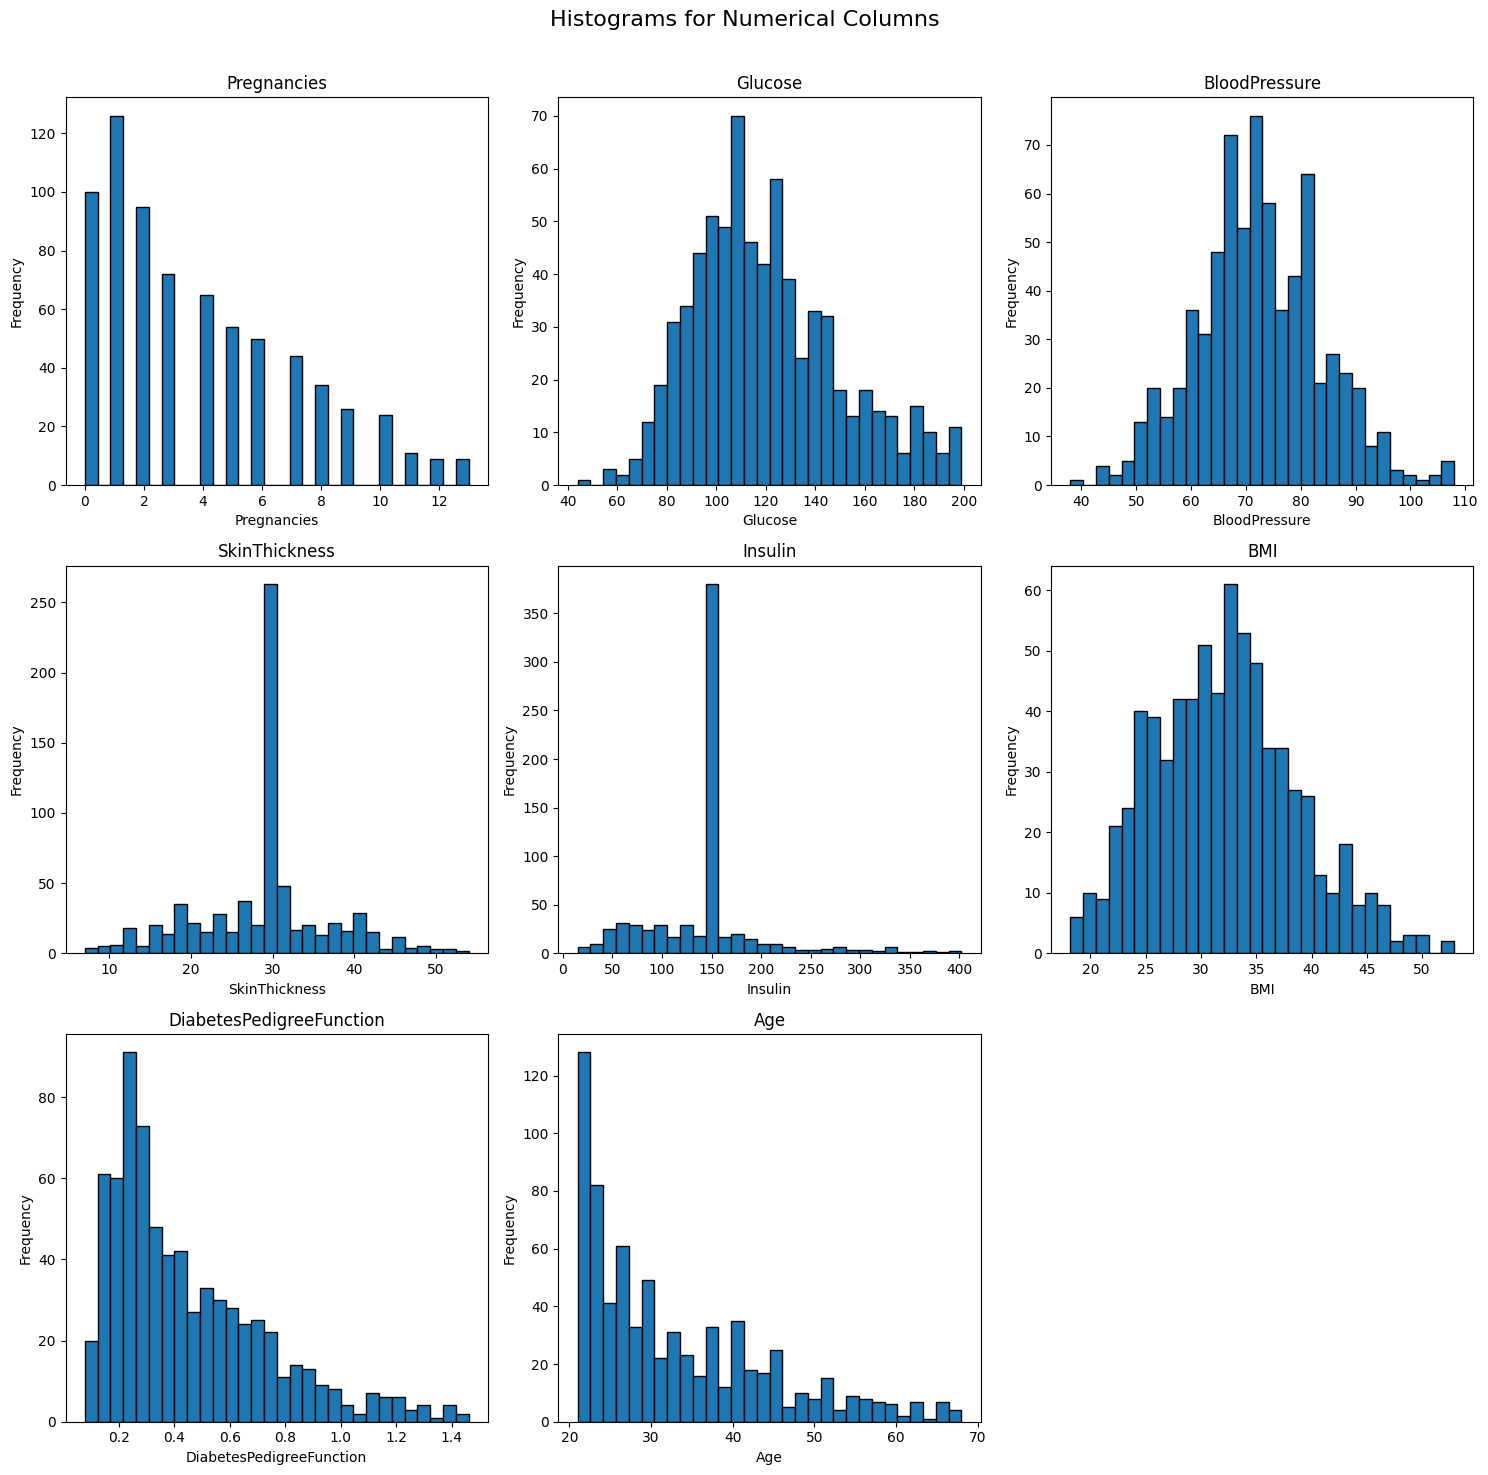

In [46]:
plot_histograms(df_no_outliers, X, title='Histograms for Numerical Columns')

# 5 Stratified 

In [51]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE  # optional
import xgboost as xgb
import numpy as np
import pandas as pd

# Separate features and target
X = df_no_outliers.drop(columns='Outcome')
y = df_no_outliers['Outcome']

# Initialize Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Metric storage
metrics = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": [],
    "roc_auc": [],
    "confusion_matrices": []
}

# Loop over folds
for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Apply MinMax scaling to training set
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Optional: apply SMOTE on training set
    smote = SMOTE(random_state=42)
    X_train_scaled, y_train = smote.fit_resample(X_train_scaled, y_train)

    # Train XGBoost classifier
    model = xgb.XGBClassifier(
        use_label_encoder=False, 
        eval_metric='logloss', 
        n_estimators=50, 
        random_state=42
    )
    model.fit(X_train_scaled, y_train)

    # Predict
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Store metrics
    metrics["accuracy"].append(accuracy_score(y_test, y_pred))
    metrics["precision"].append(precision_score(y_test, y_pred, zero_division=0))
    metrics["recall"].append(recall_score(y_test, y_pred))
    metrics["f1"].append(f1_score(y_test, y_pred))
    metrics["roc_auc"].append(roc_auc_score(y_test, y_proba))
    metrics["confusion_matrices"].append(confusion_matrix(y_test, y_pred))

# Final average results
print("📊 Average Metrics Across 5 Folds:")
for metric, values in metrics.items():
    if metric != "confusion_matrices":
        print(f"{metric.capitalize()}: {np.mean(values):.3f} ± {np.std(values):.3f}")

# Optional: print confusion matrices per fold
for i, cm in enumerate(metrics["confusion_matrices"], 1):
    print(f"\nConfusion Matrix - Fold {i}:\n{cm}")

c:\Users\nigel\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [13:58:47] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\nigel\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [13:58:47] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\nigel\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [13:58:47] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are

📊 Average Metrics Across 5 Folds:
Accuracy: 0.740 ± 0.027
Precision: 0.609 ± 0.041
Recall: 0.640 ± 0.051
F1: 0.623 ± 0.039
Roc_auc: 0.796 ± 0.032

Confusion Matrix - Fold 1:
[[76 19]
 [13 36]]

Confusion Matrix - Fold 2:
[[73 22]
 [20 29]]

Confusion Matrix - Fold 3:
[[81 15]
 [19 29]]

Confusion Matrix - Fold 4:
[[73 23]
 [18 30]]

Confusion Matrix - Fold 5:
[[74 21]
 [17 31]]


In [52]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np
import pandas as pd

# Separate features and target
X = df_no_outliers.drop(columns='Outcome')
y = df_no_outliers['Outcome']

# Initialize Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Metric storage
metrics_rf = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": [],
    "roc_auc": [],
    "confusion_matrices": []
}

# Cross-validation loop
for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Min-Max Scaling (fit on training, transform both)
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train Random Forest
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(X_train_scaled, y_train)

    # Predict
    y_pred = rf_model.predict(X_test_scaled)
    y_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

    # Store metrics
    metrics_rf["accuracy"].append(accuracy_score(y_test, y_pred))
    metrics_rf["precision"].append(precision_score(y_test, y_pred, zero_division=0))
    metrics_rf["recall"].append(recall_score(y_test, y_pred))
    metrics_rf["f1"].append(f1_score(y_test, y_pred))
    metrics_rf["roc_auc"].append(roc_auc_score(y_test, y_proba))
    metrics_rf["confusion_matrices"].append(confusion_matrix(y_test, y_pred))

# 📊 Print final averaged results
print("📊 Random Forest - Average Metrics Across 5 Folds:")
for metric, values in metrics_rf.items():
    if metric != "confusion_matrices":
        print(f"{metric.capitalize()}: {np.mean(values):.3f} ± {np.std(values):.3f}")

# Optional: print confusion matrices
for i, cm in enumerate(metrics_rf["confusion_matrices"], 1):
    print(f"\nConfusion Matrix - Fold {i}:\n{cm}")


📊 Random Forest - Average Metrics Across 5 Folds:
Accuracy: 0.759 ± 0.024
Precision: 0.667 ± 0.051
Recall: 0.574 ± 0.036
F1: 0.616 ± 0.038
Roc_auc: 0.829 ± 0.026

Confusion Matrix - Fold 1:
[[85 10]
 [18 31]]

Confusion Matrix - Fold 2:
[[83 12]
 [23 26]]

Confusion Matrix - Fold 3:
[[81 15]
 [22 26]]

Confusion Matrix - Fold 4:
[[78 18]
 [20 28]]

Confusion Matrix - Fold 5:
[[80 15]
 [20 28]]


# Min-max scale

In [15]:
# Create a copy of the DataFrame to keep original safe
df_minmax_scaled = df_no_outliers.copy()

# Initialize the scaler
scaler = MinMaxScaler()

# Fit and transform the X columns
df_minmax_scaled[X] = scaler.fit_transform(df_minmax_scaled[X])


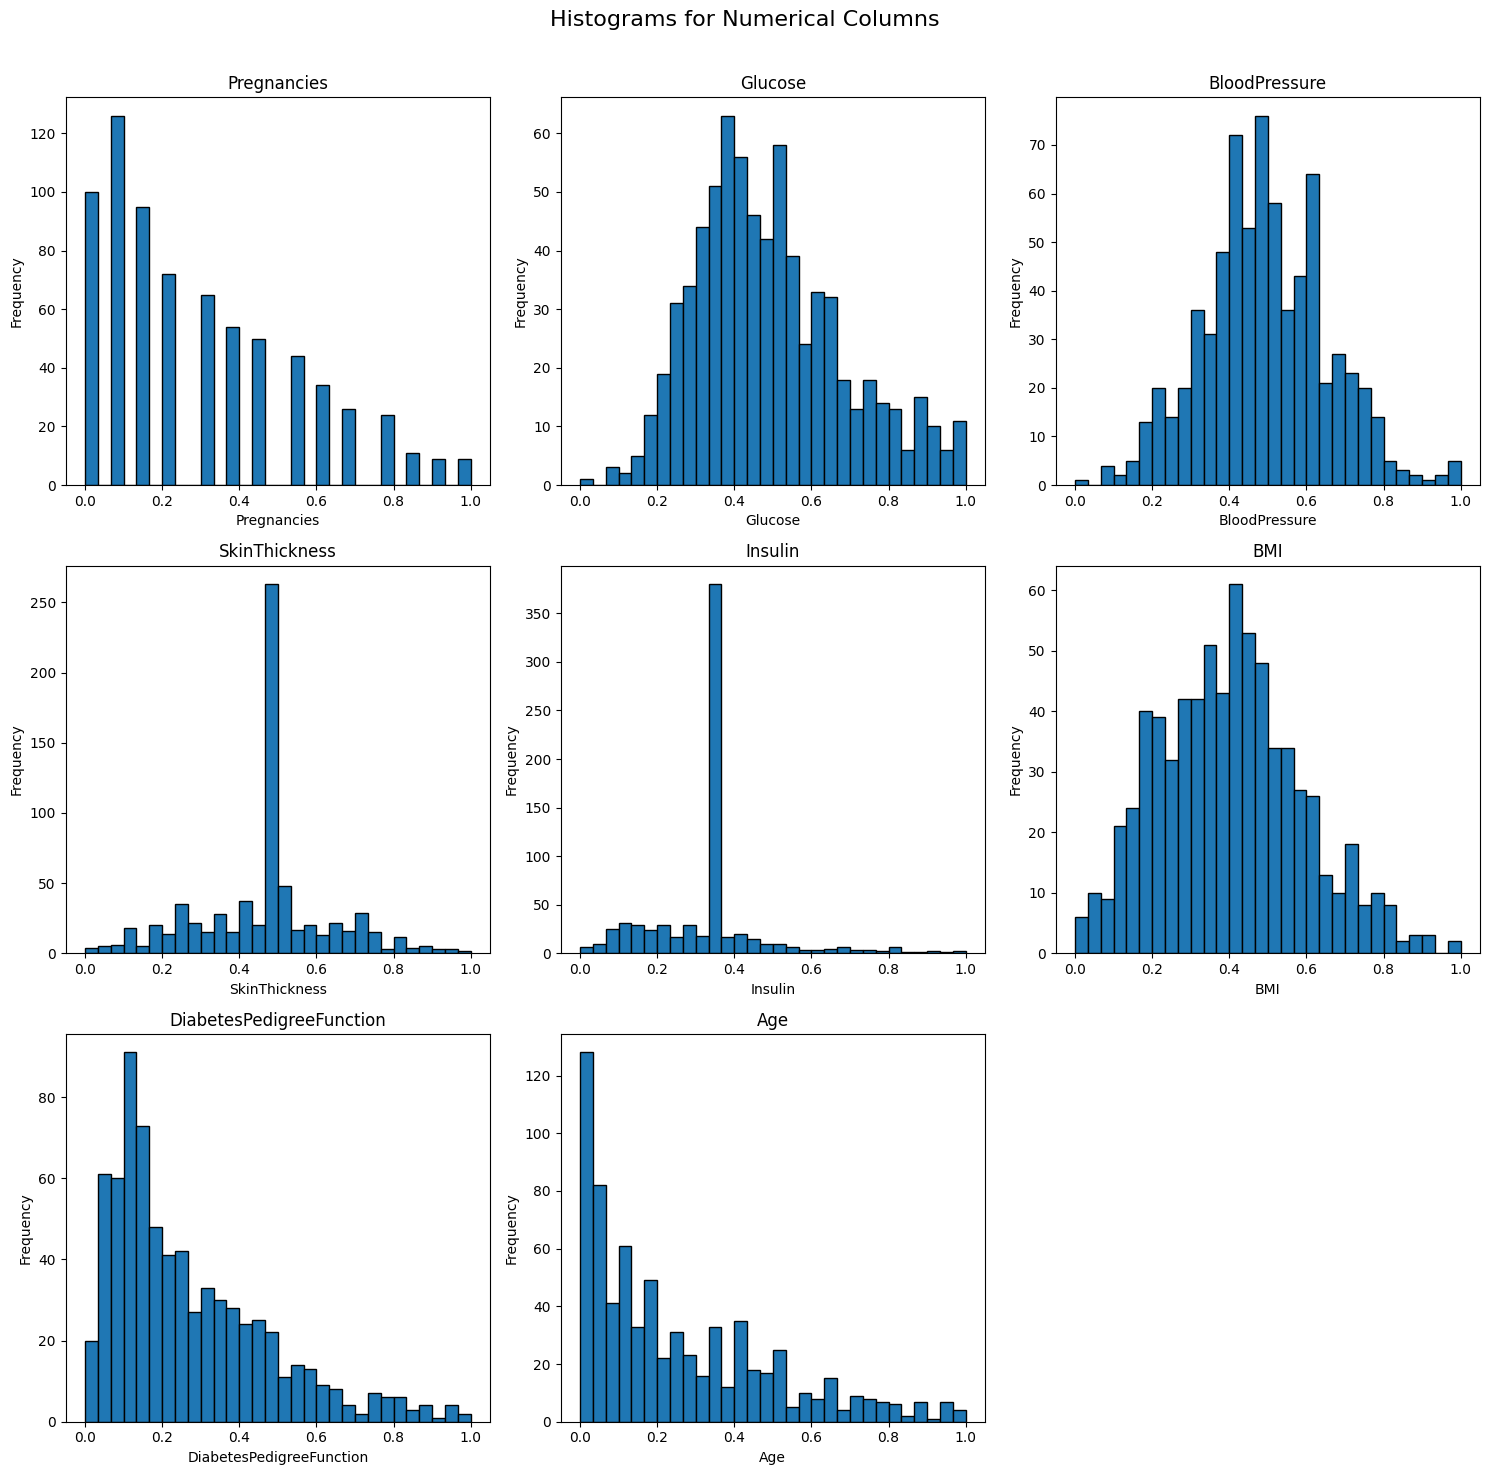

In [16]:
plot_histograms(df_minmax_scaled, X, title='Histograms for Numerical Columns')

# Standard scale

In [17]:
# Create a copy to keep the original safe
df_standard_scaled = df_no_outliers.copy()

# Choose columns to scale with StandardScaler
standard_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
                 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']  # all X columns

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the data
df_standard_scaled[standard_cols] = scaler.fit_transform(df_standard_scaled[standard_cols])

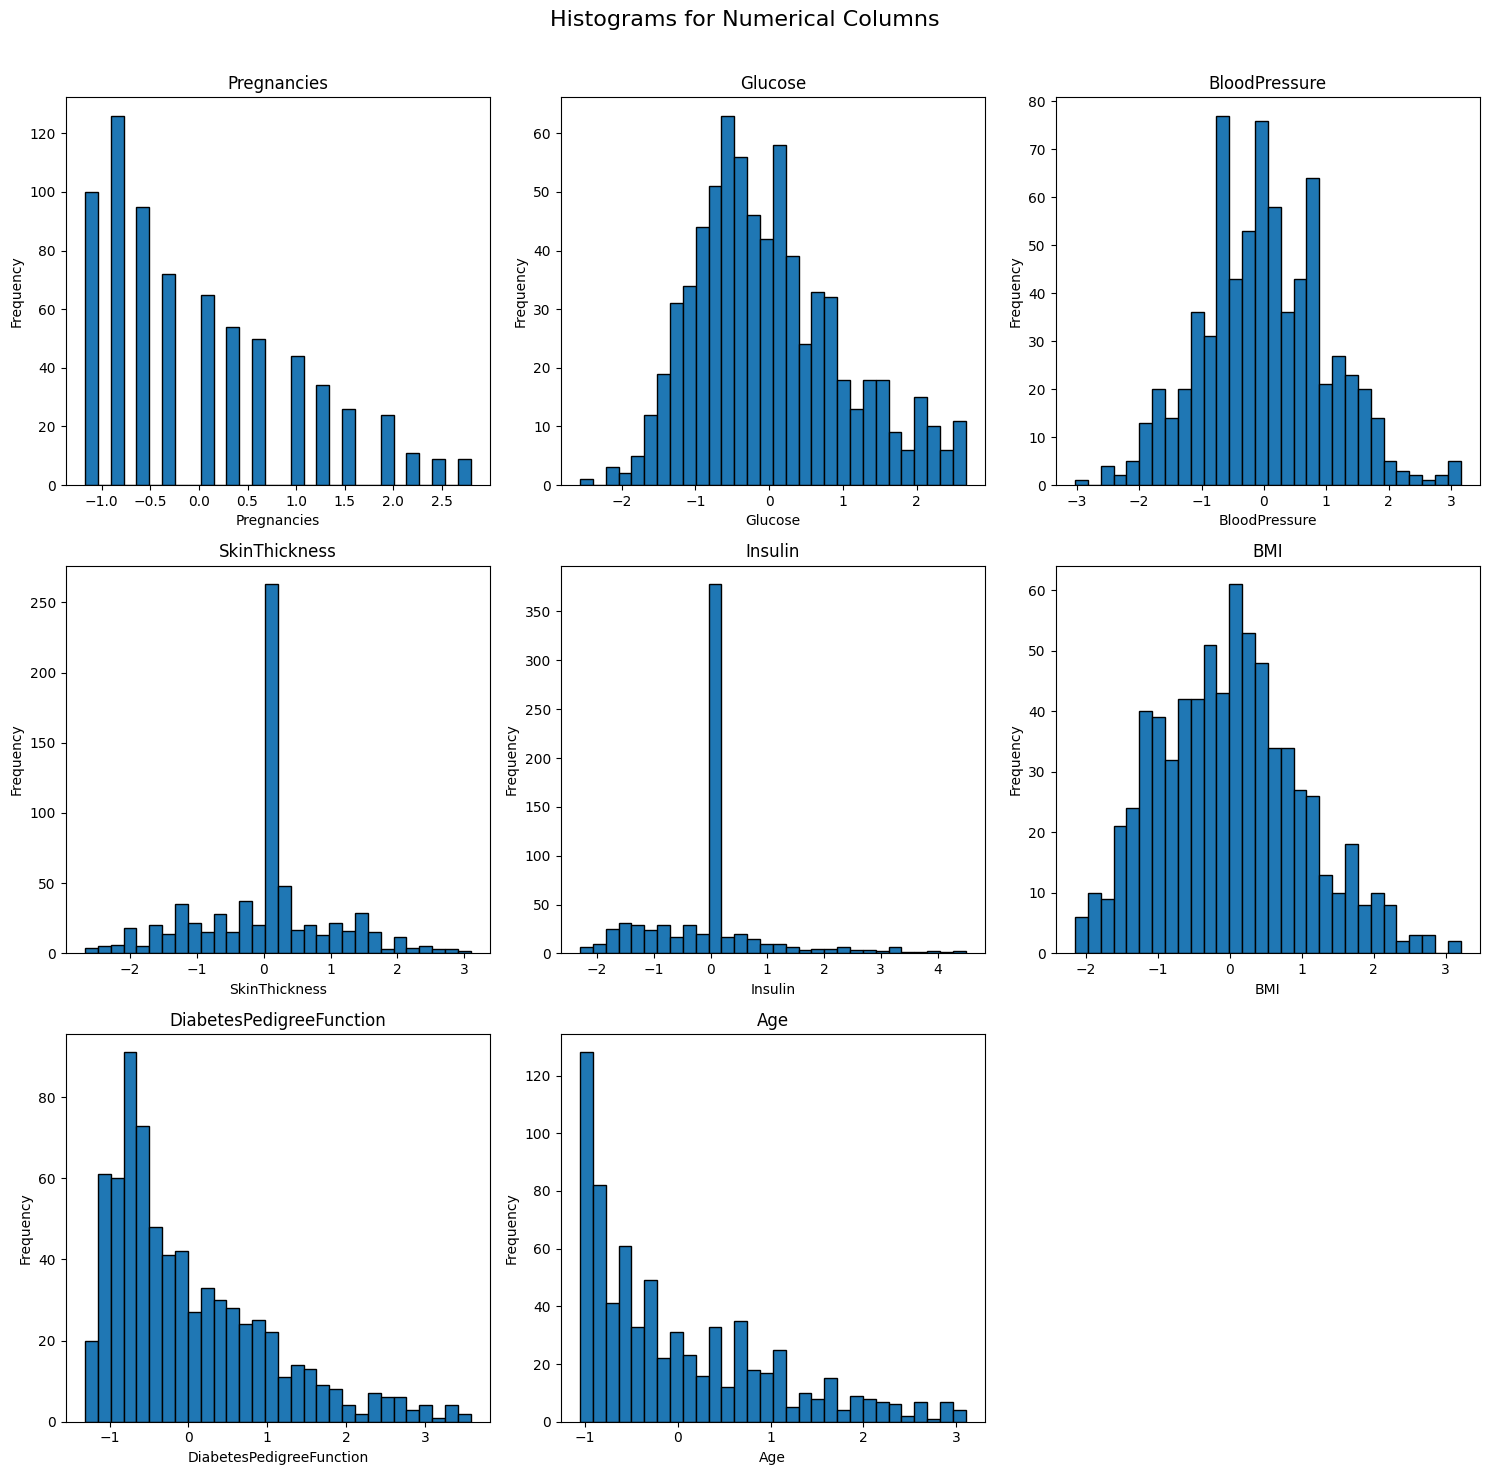

In [18]:
plot_histograms(df_standard_scaled, X, title='Histograms for Numerical Columns')

# Mix of scalers - respective to each column's distribution

# SMOTE - to handle class imbalance

In [32]:
# 1. Separate features and target
X_mm = df_minmax_scaled.drop(columns='Outcome')
y_mm = df_minmax_scaled['Outcome']

# 2. Train-test split (stratify to keep class ratio)
X_train_mm, X_test_mm, y_train_mm, y_test_mm = train_test_split(
    X_mm, y_mm, test_size=0.2, stratify=y_mm, random_state=42
)

# 3. Apply SMOTE
smote = SMOTE(random_state=42)
X_train_mm_sm, y_train_mm_sm = smote.fit_resample(X_train_mm, y_train_mm)

In [ ]:
# 1. Separate features and target
X = df_standard_scaled.drop(columns='Outcome')   # assuming 'Outcome' is your label
y = df_standard_scaled['Outcome']

# 2. Train-test split (stratify helps maintain class distribution)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 3. Apply SMOTE on training data
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Now you can train your model on X_train_sm, y_train_sm


In [20]:
print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_sm.value_counts())


Before SMOTE: Outcome
0    381
1    194
Name: count, dtype: int64
After SMOTE: Outcome
0    381
1    381
Name: count, dtype: int64


In [33]:
X_train_mm_sm.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,762.000000,762.000000,762.000000,762.000000,762.000000,762.000000,762.000000,762.000000
mean,0.311965,0.517740,0.500359,0.470048,0.344660,0.421883,0.274344,0.274955
std,0.252902,0.185703,0.160596,0.160785,0.133630,0.185354,0.204551,0.242357
min,0.000000,0.000000,0.085714,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.076923,0.380645,0.387168,0.422546,0.322997,0.291787,0.122921,0.079357
50%,0.245130,0.501205,0.491503,0.471349,0.363174,0.415867,0.211135,0.191489
75%,0.461538,0.632258,0.600000,0.531915,0.363174,0.530259,0.386793,0.425532
max,1.000000,0.987097,1.000000,1.000000,1.000000,1.000000,1.000000,0.978723


In [30]:
X_train_sm.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,762.000000,762.000000,762.000000,762.000000,762.000000,762.000000,762.000000,762.000000
mean,0.068869,0.143633,0.062114,0.043928,0.033582,0.108844,0.025038,0.088437
std,1.004804,0.973983,1.000728,0.933590,0.909072,1.000769,1.001769,1.001977
min,-1.172338,-2.567312,-2.499318,-2.671292,-2.301497,-2.154271,-1.313619,-1.054890
25%,-0.867156,-0.567083,-0.644069,-0.261360,-0.105760,-0.593345,-0.708509,-0.734756
50%,-0.139397,0.060614,0.010143,0.047173,0.167359,0.065246,-0.280331,-0.258554
75%,0.658750,0.747317,0.681109,0.396480,0.167359,0.708243,0.566292,0.714746
max,2.795019,2.597838,3.154774,3.096119,4.496505,3.208516,3.580341,3.015274


# Feature engineering